### Assignment 1 Task 2

In [13]:
import numpy as np
import math
import matplotlib.pyplot as plt
import torch as t
import random

#### a)

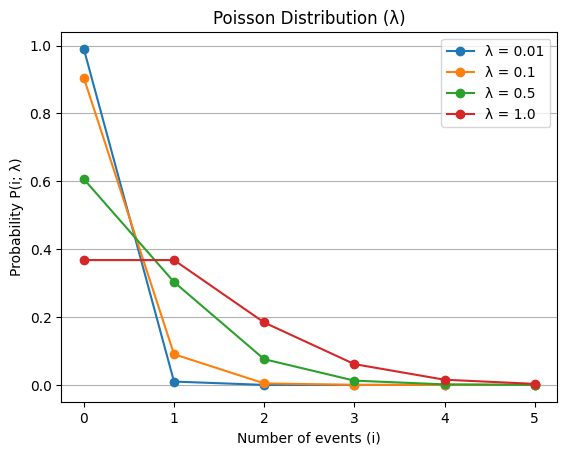

In [14]:
def poisson_probability(i,lambda_):
    return np.exp(-lambda_) * t.pow(lambda_,i) / t.tensor([math.factorial(int(x)) for x in i], 
                      dtype=t.float64)
#i=t.tensor([0,1,2,3,4,5,6,7,8,9])
#t.sum(poisson_probability(i,5.2))

def plot_poisson_distribution(number_of_events, lambdas=[0.01, 0.1, 0.5, 1.0]):
    i = t.arange(0, number_of_events)
    for lambda_ in lambdas:
        probabilities = poisson_probability(i, lambda_)
        plt.plot(i, probabilities, 'o-', label=f'λ = {lambda_}')
        #plt.bar(i.numpy(), probabilities.numpy())
    plt.xlabel('Number of events (i)')
    plt.ylabel('Probability P(i; λ)')
    plt.title(f'Poisson Distribution (λ)')
    plt.legend()

    plt.xticks(i.numpy())
    plt.grid(axis='y')
    plt.show()

plot_poisson_distribution(number_of_events=6)

#### b)

In [15]:
### Taken from https://www.johndcook.com/blog/2010/06/14/generating-poisson-random-values/
def sampling_poisson(lambda_,size):
    res=[]
    for _ in range(size):
        condition=np.exp(-lambda_)
        k=0
        p=1
        while p>condition:
            k+=1
            u=np.random.random()
            p*=u
        res.append(k-1)
    return res
X=sampling_poisson(0.1,2000)
print(X)
print(np.mean(X))


[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 

#### c)

In [16]:
def waiting_list_getter(lambda_, size=2000, processing_duration=4):
    samples=sampling_poisson(lambda_,size)
    waiting_queue=0
    processing_time=0
    processing=False
    sum_waiting_queue=0
    for sample in samples:
        waiting_queue+=sample
        if not processing:
            if waiting_queue>0:
                processing=True
                processing_time=1
                waiting_queue-=1
        else:
            processing_time+=1
            if processing_time>=processing_duration:
                processing=False
        sum_waiting_queue+=waiting_queue

    return sum_waiting_queue/size

waiting_list_getter(lambda_=0.1)

0.0835

### d)

In [17]:
def get_avg_50_iter(processing_duration, interval,num):
    final_output=[]
    for alpha in np.linspace(*interval,num=num):
        output_for_alpha=0
        for index in range(200):
            temp=waiting_list_getter(lambda_=alpha,processing_duration=processing_duration)
            output_for_alpha+=temp
        final_output.append(output_for_alpha/200)
    return final_output

In [18]:
averages=get_avg_50_iter(processing_duration=4,interval=(0.005,0.25),num=50)

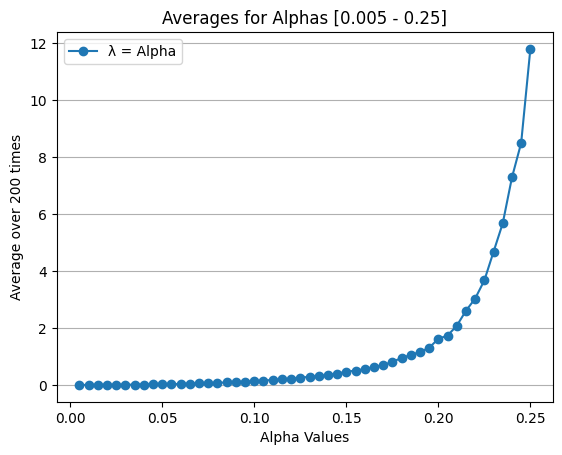

In [19]:
x=np.linspace(0.005,0.25,num=50)
plt.plot(x, averages, 'o-', label=f'λ = Alpha')
plt.xlabel('Alpha Values')
plt.ylabel('Average over 200 times')
plt.title(f'Averages for Alphas [0.005 - 0.25]')
plt.legend()
plt.grid(axis='y')
plt.show()

### e)

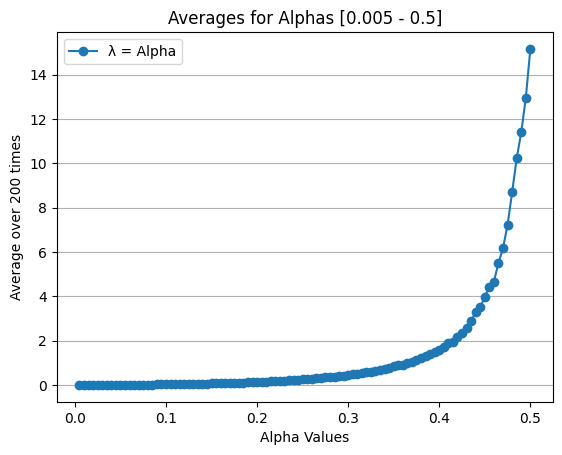

In [20]:
averages=get_avg_50_iter(processing_duration=2,interval=(0.005,0.5),num=100)
x=np.linspace(0.005,0.5,num=100)
plt.plot(x, averages, 'o-', label=f'λ = Alpha')
plt.xlabel('Alpha Values')
plt.ylabel('Average over 200 times')
plt.title(f'Averages for Alphas [0.005 - 0.5]')
plt.legend()
plt.grid(axis='y')
plt.show()

The plots are suggestign that when alpha (rate of entering processes) increases, the length of waiting queues are exponentionally increasing.